In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
path_raw = Path('/data/globus/jbassham/thesis-rough/raw/south/04012026_1740')
path_regrid = Path('/data/globus/jbassham/thesis-rough/regrid/south/04012026_1740')

In [3]:
fnam_raw = 'ice_vel_raw_nsidc0016v4_ease.npz'
fnam_regrid = 'ice_vel_regrid_nsidc0016v4.npz'

In [4]:
data_raw = np.load(path_raw / fnam_raw)
data_regrid = np.load(path_regrid / fnam_regrid)

In [5]:
time_index = 0

ymin_raw, ymax_raw = (150, 300)
xmin_raw, xmax_raw = (50, 150)

ymin_regrid, ymax_regrid = (0, 80) 
xmin_regrid, xmax_regrid = (110, 290)

In [6]:
data_regrid['lon'].shape

(522,)

In [7]:
data_regrid['lat'].shape

(81,)

In [8]:
print(data_regrid['lon'])

[-1.80000000e+02 -1.79308209e+02 -1.78616417e+02 -1.77924626e+02
 -1.77232835e+02 -1.76541043e+02 -1.75849252e+02 -1.75157461e+02
 -1.74465669e+02 -1.73773878e+02 -1.73082087e+02 -1.72390295e+02
 -1.71698504e+02 -1.71006713e+02 -1.70314921e+02 -1.69623130e+02
 -1.68931339e+02 -1.68239547e+02 -1.67547756e+02 -1.66855965e+02
 -1.66164173e+02 -1.65472382e+02 -1.64780591e+02 -1.64088800e+02
 -1.63397008e+02 -1.62705217e+02 -1.62013426e+02 -1.61321634e+02
 -1.60629843e+02 -1.59938052e+02 -1.59246260e+02 -1.58554469e+02
 -1.57862678e+02 -1.57170886e+02 -1.56479095e+02 -1.55787304e+02
 -1.55095512e+02 -1.54403721e+02 -1.53711930e+02 -1.53020138e+02
 -1.52328347e+02 -1.51636556e+02 -1.50944764e+02 -1.50252973e+02
 -1.49561182e+02 -1.48869390e+02 -1.48177599e+02 -1.47485808e+02
 -1.46794016e+02 -1.46102225e+02 -1.45410434e+02 -1.44718642e+02
 -1.44026851e+02 -1.43335060e+02 -1.42643268e+02 -1.41951477e+02
 -1.41259686e+02 -1.40567894e+02 -1.39876103e+02 -1.39184312e+02
 -1.38492520e+02 -1.37800

In [9]:
print(data_regrid['lat'])

[-80.         -79.77477477 -79.54954955 -79.32432432 -79.0990991
 -78.87387387 -78.64864865 -78.42342342 -78.1981982  -77.97297297
 -77.74774775 -77.52252252 -77.2972973  -77.07207207 -76.84684685
 -76.62162162 -76.3963964  -76.17117117 -75.94594595 -75.72072072
 -75.4954955  -75.27027027 -75.04504505 -74.81981982 -74.59459459
 -74.36936937 -74.14414414 -73.91891892 -73.69369369 -73.46846847
 -73.24324324 -73.01801802 -72.79279279 -72.56756757 -72.34234234
 -72.11711712 -71.89189189 -71.66666667 -71.44144144 -71.21621622
 -70.99099099 -70.76576577 -70.54054054 -70.31531532 -70.09009009
 -69.86486486 -69.63963964 -69.41441441 -69.18918919 -68.96396396
 -68.73873874 -68.51351351 -68.28828829 -68.06306306 -67.83783784
 -67.61261261 -67.38738739 -67.16216216 -66.93693694 -66.71171171
 -66.48648649 -66.26126126 -66.03603604 -65.81081081 -65.58558559
 -65.36036036 -65.13513514 -64.90990991 -64.68468468 -64.45945946
 -64.23423423 -64.00900901 -63.78378378 -63.55855856 -63.33333333
 -63.108108

In [ ]:
raw_bounds = {
    'y': (150, 300),
    'x': (50, 150),
}

regrid_bounds = {
    'y': (0, 80), 
    'x': (110, 290),
}

In [30]:
def plot_original_and_regrid(
        data_raw, data_regrid,
        time_index,
        var_name: str,
        raw_bounds: None | dict = None,
        regrid_bounds: None | dict = None,
        ) -> None:
    """
    
    """
    fig, axs = plt.subplots(
        nrows = 2, ncols = 1, figsize = (6, 6), constrained_layout = True,
    )

    if raw_bounds is not None:     
        pcm0 = axs[0].pcolormesh(
            data_raw['x'][raw_bounds['x'][0]:raw_bounds['x'][1]],
            data_raw['y'][raw_bounds['y'][0]:raw_bounds['y'][1]],
            data_raw[var_name][
                 time_index, 
                 raw_bounds['y'][0]:raw_bounds['y'][1], 
                 raw_bounds['x'][0]:raw_bounds['x'][1]
                 ]
        )

    else:
            pcm0 = axs[0].pcolormesh(
            data_raw['x'],
            data_raw['y'],
            data_raw[var_name][time_index]
        )
            
    axs[0].set_title('Raw')
    plt.colorbar(pcm0, ax = axs[0], orientation = 'vertical')

    if regrid_bounds is not None:  
        pcm1 = axs[1].pcolormesh(
            data_regrid['lon'][regrid_bounds['x'][0]:regrid_bounds['x'][1]],
            data_regrid['lat'][regrid_bounds['y'][0]:regrid_bounds['y'][1]],
            data_regrid[var_name][
                time_index, 
                regrid_bounds['y'][0]:regrid_bounds['y'][1], 
                regrid_bounds['x'][0]:regrid_bounds['x'][1]
                ]
            )
        
    else:
        pcm1 = axs[1].pcolormesh(
            data_regrid['lon'],
            data_regrid['lat'],
            data_regrid[var_name][time_index]
            )

    axs[1].set_title('Regrid')
    plt.colorbar(pcm1, ax = axs[1], orientation = 'vertical')


    fig.suptitle(var_name, fontweight = 'bold')

    plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

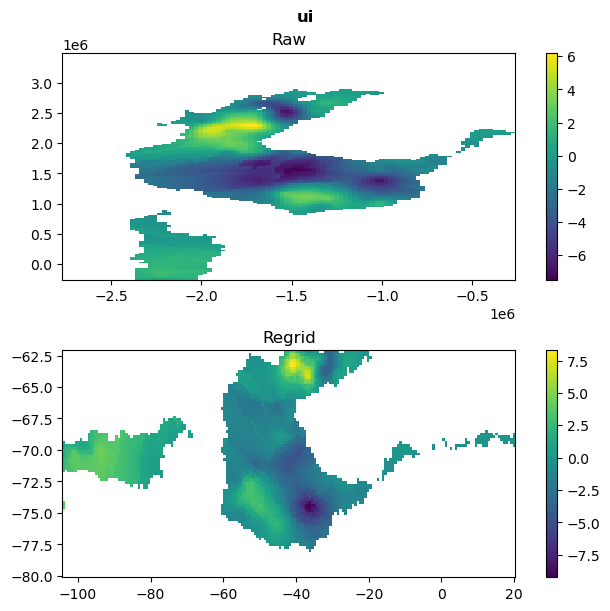

In [11]:
fig, axs = plt.subplots(
    nrows = 2, ncols = 1, figsize = (6, 6), constrained_layout = True,
)

pcm0 = axs[0].pcolormesh(
    data_raw['x'][xmin_raw:xmax_raw],
    data_raw['y'][ymin_raw:ymax_raw],
    data_raw['ui'][time_index, ymin_raw:ymax_raw, xmin_raw:xmax_raw]
)
axs[0].set_title('Raw')
plt.colorbar(pcm0, ax = axs[0], orientation = 'vertical')

pcm1 = axs[1].pcolormesh(
    data_regrid['lon'][xmin_regrid:xmax_regrid],
    data_regrid['lat'][ymin_regrid:ymax_regrid],
    data_regrid['ui'][time_index, ymin_regrid:ymax_regrid, xmin_regrid:xmax_regrid]
    )

axs[1].set_title('Regrid')
plt.colorbar(pcm1, ax = axs[1], orientation = 'vertical')


fig.suptitle('ui', fontweight = 'bold')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

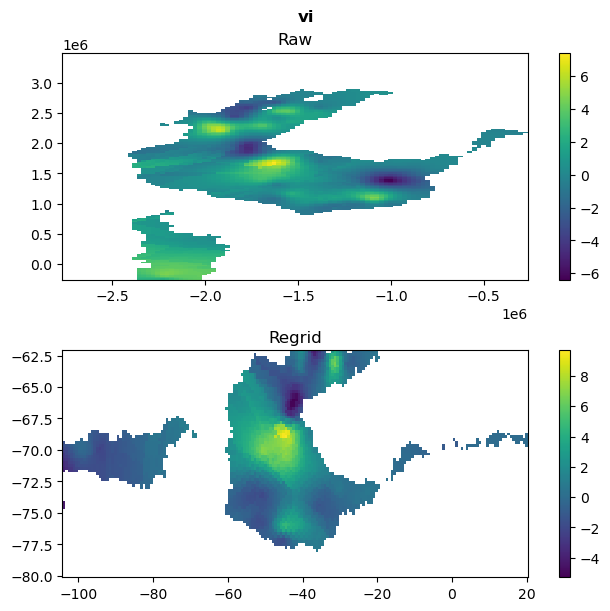

In [12]:
fig, axs = plt.subplots(
    nrows = 2, ncols = 1, figsize = (6, 6), constrained_layout = True,
)

pcm0 = axs[0].pcolormesh(
    data_raw['x'][xmin_raw:xmax_raw],
    data_raw['y'][ymin_raw:ymax_raw],
    data_raw['vi'][time_index, ymin_raw:ymax_raw, xmin_raw:xmax_raw]
    )

axs[0].set_title('Raw')
plt.colorbar(pcm0, ax = axs[0], orientation = 'vertical')

pcm1 = axs[1].pcolormesh(
    data_regrid['lon'][xmin_regrid:xmax_regrid],
    data_regrid['lat'][ymin_regrid:ymax_regrid],
    data_regrid['vi'][time_index, ymin_regrid:ymax_regrid, xmin_regrid:xmax_regrid]
    )

axs[1].set_title('Regrid')
plt.colorbar(pcm1, ax = axs[1], orientation = 'vertical')


fig.suptitle('vi', fontweight = 'bold')

plt.show

In [13]:
speed_raw = np.sqrt(data_raw['ui'] ** 2 + data_raw['vi'] ** 2)
speed_regrid = np.sqrt(data_regrid['ui'] ** 2 + data_regrid['vi'] ** 2)

<function matplotlib.pyplot.show(close=None, block=None)>

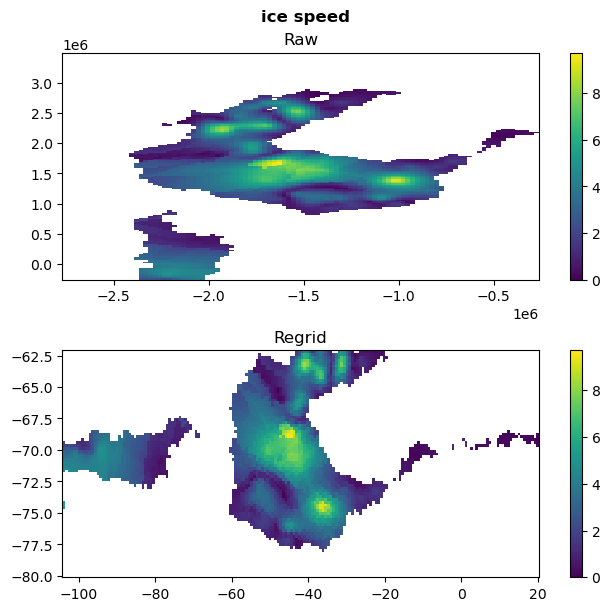

In [14]:
fig, axs = plt.subplots(
    nrows = 2, ncols = 1, figsize = (6, 6), constrained_layout = True,
)

pcm0 = axs[0].pcolormesh(
    data_raw['x'][xmin_raw:xmax_raw],
    data_raw['y'][ymin_raw:ymax_raw],
    speed_raw[time_index, ymin_raw:ymax_raw, xmin_raw:xmax_raw],
    )
axs[0].set_title('Raw')
plt.colorbar(pcm0, ax = axs[0], orientation = 'vertical')

pcm1 = axs[1].pcolormesh(
    data_regrid['lon'][xmin_regrid:xmax_regrid],
    data_regrid['lat'][ymin_regrid:ymax_regrid],
    speed_regrid[time_index, ymin_regrid:ymax_regrid, xmin_regrid:xmax_regrid]
    )

axs[1].set_title('Regrid')
plt.colorbar(pcm1, ax = axs[1], orientation = 'vertical')


fig.suptitle('ice speed', fontweight = 'bold')

plt.show

In [18]:
fnam_raw = 'ice_conc_raw_nsidc0051v2_ps.npz'
fnam_regrid = 'ice_conc_regrid_nsidc0051v2.npz'

In [19]:
data_raw = np.load(path_raw / fnam_raw)
data_regrid = np.load(path_regrid / fnam_regrid)

In [36]:
raw_bounds = {
    'y': (50, 150),
    'x': (50, 150)
}

regrid_bounds = {
    'y': (0, 150),
    'x': (110, 290)
}

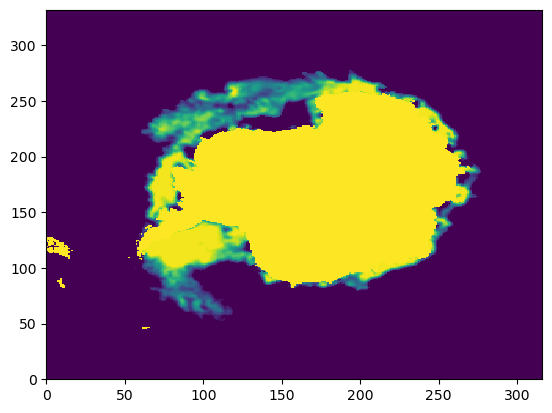

In [23]:
plt.pcolormesh(data_raw['ci'][0])

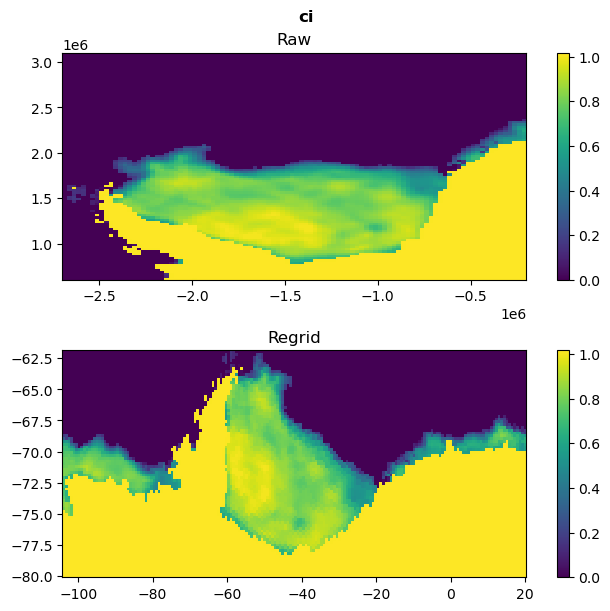

In [38]:
time_index = 100

plot_original_and_regrid(
    data_raw, data_regrid,
    time_index,
    'ci',
    raw_bounds = raw_bounds,
    regrid_bounds = regrid_bounds,
)